## Homework 2: Company Fundamental Deep Dive - Group 3(United Kingdom) 

**Course:** Big Data Analytics  
**Professor:** Giovanni Morana  
**Student:** Carmen Padova  
**Student ID:** 100003559(4) → Group 3 (United Kingdom) 

In [77]:
# ==================================================================================
# PRELIMINARY SETUP — Libraries, Dataset Loading, Geographic Filtering and Screening 
# ==================================================================================
# Before selecting the company, we inspect the available UK firms.
# This preliminary screening helps identify companies with meaningful
# market capitalization, profitability, growth, and valuation profiles
# that can generate an interesting peer comparison in the following steps.

# 1. LIBRARY IMPORTS

import pandas as pd              # pandas: used for data loading, cleaning, filtering and aggregation.
import numpy as np               # numpy: used for numerical operations and handling missing/infinite values.
import matplotlib.pyplot as plt  # matplotlib: used for basic chart creation and layout customization.
import seaborn as sns            # seaborn: extension of matplotlib, used for statistical visualizations and advanced charts.


# 2. PLOT STYLE SETTINGS

# We use the "whitegrid" theme to ensure charts are readable and consistent with a data analysis report.
sns.set_theme(style='whitegrid')


# 3. DATASET LOADING

# The dataset is loaded into a pandas DataFrame.
df_raw = pd.read_csv('data/Symbol_Info_extended.csv')


# 4. GEOGRAPHIC FILTERING

# Based on the last digit of the Student ID (Group 3),
# we filter the raw dataset to isolate companies based in the United Kingdom.
df_uk = df_raw[df_raw['country'] == 'United Kingdom'].copy()


# 5. RESULTS VERIFICATION

# We print the row count before and after filtering to verify that the process was successful.
print(f'Total rows in the original dataset: {len(df_raw)}')
print(f'Available companies in Group 3 (United Kingdom): {len(df_uk)}\n')


# 6. VISUAL INSPECTION FOR SELECTION

# We extract and print core variables to examine the available candidates before Step 0.
screening_columns = [
    'symbol', 'company_name', 'sector', 'industry', 'market_cap', 
    'profit_margins', 'return_on_equity', 'pe_trailing', 'revenue_growth', 'debt_to_equity'
]
df_uk_screening = df_uk[screening_columns].sort_values(by='market_cap', ascending=False)

# Force text format printing to ensure notebook stability and avoid HTML layout freezing
print('UK companies:')
print(df_uk_screening.to_string(index=False))

Total rows in the original dataset: 3070
Available companies in Group 3 (United Kingdom): 24

UK companies:
symbol                                company_name             sector                                 industry   market_cap  profit_margins  return_on_equity  pe_trailing  revenue_growth  debt_to_equity
   ARM                            Arm Holdings plc         Technology                           Semiconductors 3.261262e+11         0.18374           0.11954   356.406980           0.201           5.214
   AZN                             AstraZeneca PLC         Healthcare             Drug Manufacturers - General 2.900551e+11         0.17189           0.23483    28.167170           0.125          71.815
   LIN                                   Linde plc    Basic Materials                      Specialty Chemicals 2.393017e+11         0.20436           0.18229    34.367863           0.082          65.642
  CCEP          Coca-Cola Europacific Partners PLC Consumer Defensive           

## **Step 0 - Select a Company** 

In [78]:
# =========================================================================
# 1. TARGET COMPANY SELECTION & JUSTIFICATION
# =========================================================================
# Target Company Selected: AstraZeneca PLC (Symbol: AZN)
# Justification: 
# ============================================================
# I selected AstraZeneca (AZN) for this analysis. During the preliminary
# screening of UK companies, AstraZeneca stood out because it combines
# 3 characteristics that do not always coexist: 
# 1) large scale as a leader in the Drug Manufacturers industry, 
# 2) strong profitability, 
# 3) sustained growth. 
# With a market_cap of approximately $290 billion, it's one of the largest companies in the
# dataset, yet it still reports high profit_margins (17.2%) and a return_on_equity (23.5%), 
# indicating efficient value creation despite its size.
# In addition, its revenue_growth (12.5%) suggests that the company continues
# to expand while maintaining strong financial performance. 
# This balance between scale, profitability, and growth makes AstraZeneca 
# a particularly interesting candidate for peer comparison throughout the analysis.



target_symbol = "AZN"
df_target = df_uk[df_uk["symbol"] == target_symbol].copy()


# 2. RESULTS VERIFICATION

# We print the counts and confirm that the target company exists in our filtered geographic pool.
print(f"Target company successfully isolated: {df_target['company_name'].values[0]} ({target_symbol})")


# 3. TARGET DATA INSPECTION

# Brief visual inspection of the target company's available records before proceeding to data cleaning.
df_target[["symbol", "company_name", "sector", "industry", "market_cap", "profit_margins", "return_on_equity", "revenue_growth"]]

Target company successfully isolated: AstraZeneca PLC (AZN)


,symbol,company_name,sector,industry,market_cap,profit_margins,return_on_equity,revenue_growth
300,AZN,AstraZeneca PLC,Healthcare,Drug Manufacturers - General,2.900551e+11,0.17189,0.23483,0.125


## **Step 1 - Data Preparation** 

In [79]:
# =========================================================================
# STEP 1 — DATA PREPARATION & CLEANING
# =========================================================================

# --- 1. LOADING THE DATASET ---
# Load the original CSV file to begin data preprocessing
df_raw = pd.read_csv('data/Symbol_Info_extended.csv')


# --- 2. SELECTION OF REQUIRED VARIABLES ---
# Define the list of the 14 specific columns explicitly required by the guidelines

# Identification and peer selection variables
id_vars = ["symbol", 
            "company_name", 
            "sector",
            "industry", 
            "country", 
            "market_cap"]

# Financial variables for the deep-dive analysis
fin_vars = [
    "return_on_assets",
    "return_on_equity",
    "profit_margins",
    "pe_trailing",
    "price_to_book",
    "revenue_growth",
    "debt_to_equity",
    "free_cashflow",
]

# Combine both lists to isolate the required columns
required_columns = id_vars + fin_vars

# Create the working DataFrame ("df") by filtering only the selected columns
df = df_raw[required_columns].copy()


# --- 3. APPLYING CLEANING RULES ---

# Rule (1): Replace infinite values (inf) with NaN
# Remove infinite values that mathematically result from dividing by zero 
# (e.g., if a company has zero revenue or zero equity). They are not valid observations.
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Rule (2): Exclude companies with a Market Cap less than or equal to zero
# A non-positive market cap indicates a data quality issue, not a small company.
# Filter the dataset to retain only strictly positive values.
df = df[df["market_cap"] > 0]

# Rule (3): Handle negative or zero valuation multiples (P/E and P/B)
# A negative P/E (loss-making company) or a negative P/B (negative book equity)
# would distort the visual scale of the charts. Convert them to NaN to exclude them from the plots.
df.loc[df["pe_trailing"] <= 0, "pe_trailing"] = np.nan
df.loc[df["price_to_book"] <= 0, "price_to_book"] = np.nan


# --- 4. FINAL DATA VERIFICATION ---
# Print a quick summary to confirm the correct execution of the cell
print("Working DataFrame successfully created and cleaned!")
print(f"Total number of companies available for analysis: {len(df)}")

# Display the preview of the first 5 rows of the cleaned dataset
df.head()

Working DataFrame successfully created and cleaned!
Total number of companies available for analysis: 2970


,symbol,company_name,sector,industry,country,market_cap,return_on_assets,return_on_equity,profit_margins,pe_trailing,price_to_book,revenue_growth,debt_to_equity,free_cashflow
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research,United States,3.248796e+10,0.08533,0.19946,0.18259,25.377481,4.704534,0.070,51.390,8.558750e+08
1,AA,Alcoa Corporation,Basic Materials,Aluminum,United States,1.883646e+10,0.04241,0.15427,0.08171,18.302563,2.759500,-0.052,37.019,1.087375e+09
2,AAL,American Airlines Group Inc.,Industrials,Airlines,United States,9.160185e+09,0.01846,NaN,0.00361,44.677420,NaN,0.108,NaN,8.611250e+08
3,AAMI,Acadian Asset Management Inc.,Financial Services,Asset Management,United States,2.550323e+09,0.12664,1.11725,0.13785,30.459576,32.910347,0.393,346.579,1.208000e+08
4,AAOI,"Applied Optoelectronics, Inc.",Technology,Communication Equipment,United States,1.456326e+10,-0.03317,-0.06126,-0.08548,NaN,12.958943,0.514,25.356,-4.455833e+08


## **Step 2 - Build Peer Groups** 

In [80]:
# =========================================================================
# STEP 2 — PEER GROUPS SELECTION (DEFINITIVE & LITERAL VERSION)
# =========================================================================

# --- 1. REQUIRED PRELIMINARY SETUP ---
# General Rule: If company_name is missing, fallback to the stock symbol as the label
df["display_name"] = df["company_name"].fillna(df["symbol"])

# Extract AstraZeneca's (Target) row as a clean baseline profile
company = df[df["symbol"] == "AZN"].iloc[0]


# --- 2. GROUP A: SAME INDUSTRY ---
# Filter companies belonging to the same industry using the target company profile
pool_A = df[df["industry"] == company["industry"]]

# Sort by market capitalization descending and select the top 10
# ASSIGNMENT NOTE: If pool_A contains fewer than 10 companies, .head(10) automatically retains all of them.
df_group_A = pool_A.sort_values(by="market_cap", ascending=False).head(10).copy()

# Conditional Rule: If AstraZeneca is not in the top 10, append it manually (creating a group of 11 companies)
if "AZN" not in df_group_A["symbol"].values:
    target_row_A = pool_A[pool_A["symbol"] == "AZN"]
    df_group_A = pd.concat([df_group_A, target_row_A])
    df_group_A = df_group_A.sort_values(by="market_cap", ascending=False)


# --- 3. GROUP B: SAME GEOGRAPHIC GROUP (UK) ---
# Select all companies located in the assigned geographic group (United Kingdom)
pool_B = df[df["country"] == "United Kingdom"]

# Sort by market capitalization descending and select the top 10
# ASSIGNMENT NOTE: If pool_B contains fewer than 10 companies, .head(10) automatically retains all of them.
df_group_B = pool_B.sort_values(by="market_cap", ascending=False).head(10).copy()

# Conditional Rule: If AstraZeneca is not in the top 10, append it manually
if "AZN" not in df_group_B["symbol"].values:
    target_row_B = pool_B[pool_B["symbol"] == "AZN"]
    df_group_B = pd.concat([df_group_B, target_row_B])
    df_group_B = df_group_B.sort_values(by="market_cap", ascending=False)


# --- 4. GROUP C: CLOSEST MARKET CAPITALIZATION ---
# Create an isolated copy to protect the main dataset from temporary columns
df_pool_C = df.copy()

# Calculate the absolute market cap distance relative to AstraZeneca
df_pool_C["mcap_distance"] = (df_pool_C["market_cap"] - company["market_cap"]).abs()

# EXPLICIT REQUIREMENT: Sort by market cap distance and retain the 10 closest companies
# ASSIGNMENT NOTE: If fewer than 10 valid companies are available, .head(10) automatically takes all of them.
df_group_C = df_pool_C.sort_values(by="mcap_distance", ascending=True).head(10).copy()


# --- 5. DISPLAYING THE TABLES ---
# Define the standard columns to display to maintain a clean visual output
view_columns = ["symbol", "display_name", "market_cap"]

print("  GROUP A: SAME INDUSTRY (Sorted by Market Cap Descending) ")
display(df_group_A[view_columns])

print("\n  GROUP B: SAME UK GEOGRAPHY (Sorted by Market Cap Descending) ")
display(df_group_B[view_columns])

print("\n  GROUP C: SORTED BY MARKET CAP DISTANCE (The 10 Closest Peers) ")
# Include the mcap_distance column to clearly demonstrate the required distance-based sorting
display(df_group_C[view_columns + ["mcap_distance"]])

  GROUP A: SAME INDUSTRY (Sorted by Market Cap Descending) 


,symbol,display_name,market_cap
1634,LLY,Eli Lilly and Company,9.497046e+11
1496,JNJ,Johnson & Johnson,5.641072e+11
9,ABBV,AbbVie Inc.,3.810972e+11
1816,MRK,"Merck & Co., Inc.",3.023312e+11
300,AZN,AstraZeneca PLC,2.900551e+11
149,AMGN,Amgen Inc.,1.831230e+11
1182,GILD,"Gilead Sciences, Inc.",1.668173e+11
2131,PFE,Pfizer Inc.,1.476156e+11
411,BMY,Bristol-Myers Squibb Company,1.214216e+11
373,BIIB,Biogen Inc.,2.860617e+10



  GROUP B: SAME UK GEOGRAPHY (Sorted by Market Cap Descending) 


,symbol,display_name,market_cap
218,ARM,Arm Holdings plc,3.261262e+11
300,AZN,AstraZeneca PLC,2.900551e+11
1625,LIN,Linde plc,2.393017e+11
523,CCEP,Coca-Cola Europacific Partners PLC,4.167418e+10
1120,FTI,TechnipFMC plc,2.830385e+10
1973,NVT,nVent Electric plc,2.662889e+10
3011,WTW,Willis Towers Watson Public Limited Company,2.431091e+10
1689,LYB,LyondellBasell Industries N.V.,2.250455e+10
2355,ROIV,Roivant Sciences Ltd.,2.154934e+10
2971,WIZEY,Wise Group PLC,1.449383e+10



  GROUP C: SORTED BY MARKET CAP DISTANCE (The 10 Closest Peers) 


,symbol,display_name,market_cap,mcap_distance
300,AZN,AstraZeneca PLC,2.900551e+11,0.000000e+00
1235,GS,"The Goldman Sachs Group, Inc.",2.940427e+11,3.987603e+09
2180,PM,Philip Morris International Inc.,2.945520e+11,4.496916e+09
2783,TXN,Texas Instruments Incorporated,2.814098e+11,8.645345e+09
1169,GEV,GE Vernova Inc.,2.791302e+11,1.092492e+10
1816,MRK,"Merck & Co., Inc.",3.023312e+11,1.227611e+10
1274,HD,"The Home Depot, Inc.",3.118264e+11,2.177126e+10
2389,RY,Royal Bank of Canada,2.637949e+11,2.626024e+10
1157,GE,GE Aerospace,3.164162e+11,2.636107e+10
1823,MS,Morgan Stanley,3.170816e+11,2.702646e+10


## **Step 3 - Business Question 1: Is the Company Profitable?** 

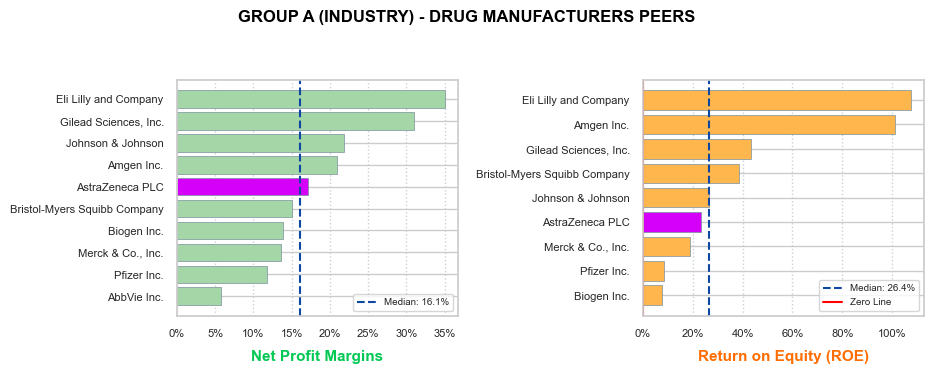

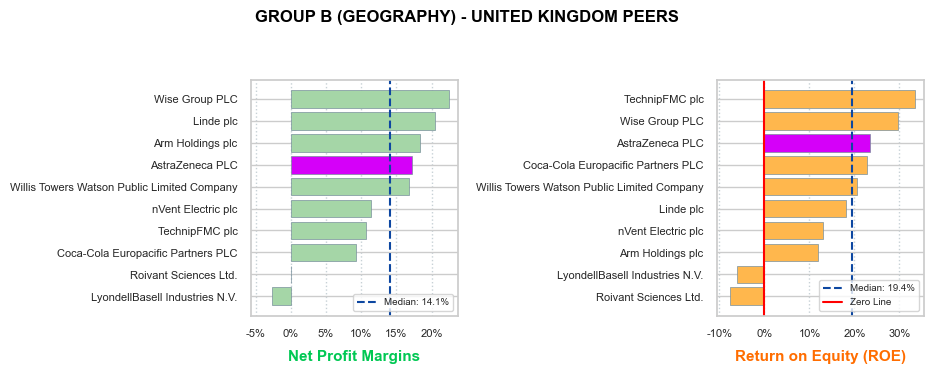

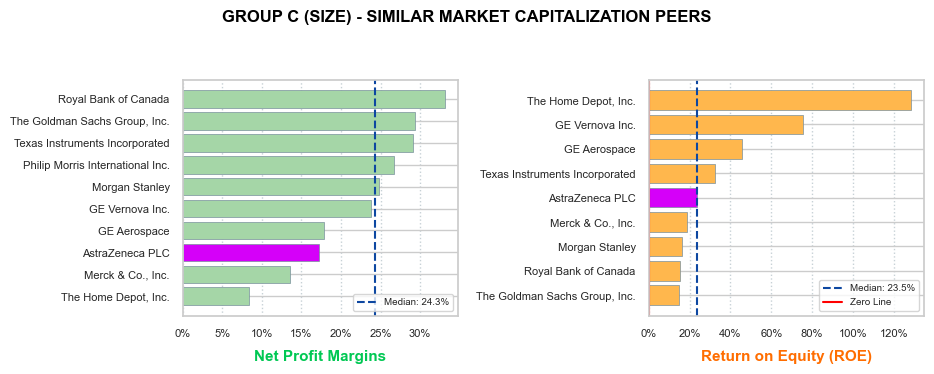

In [84]:
# =========================================================================
# STEP 3 — PROFITABILITY ANALYSIS 
# =========================================================================

# 1. DATA PREPARATION: Drop NaN values specifically for the metrics used
# This ensures that companies without profitability data don't distort the plots.
df_A_pm = df_A.dropna(subset=["profit_margins"])
df_A_roe = df_A.dropna(subset=["return_on_equity"])

df_B_pm = df_B.dropna(subset=["profit_margins"])
df_B_roe = df_B.dropna(subset=["return_on_equity"])

df_C_pm = df_C.dropna(subset=["profit_margins"])
df_C_roe = df_C.dropna(subset=["return_on_equity"])


# 2. VISUALIZATION FUNCTION: Generates dual-axis horizontal bar charts
def plot_profitability_side_by_side(data_pm, data_roe, group_title):
    # Initialize figure with a compact size and pure white background
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.8), facecolor='#FFFFFF')
    
    # GLOBAL CONFIGURATION: Defining the corporate aesthetic
    color_target = "#D500F9"       # Target company (AZN) highlighted in vibrant Orchid/Fuchsia
    color_median = "#0D47A1"       # Group Median represented by a deep Navy Blue line
    color_zero = "#FF0000"         # ROE Zero Line highlighted in high-contrast Red
    color_text_main = "#000000"    # Main titles in professional solid Black
    
    # Metrics-specific theme colors
    color_title_pm = "#00C853"     # Green theme for Profit Margins
    color_peers_pm = "#A5D6A7"     
    color_title_roe = "#FF6D00"    # Orange theme for ROE
    color_peers_roe = "#FFB74D"    
    
    # ---------------------------------------------------------------------
    # LEFT PLOT: Net Profit Margins
    # ---------------------------------------------------------------------
    data_pm_sorted = data_pm.sort_values("profit_margins")
    # Identify AZN vs Peers for coloring
    colors_pm = [color_target if s == "AZN" else color_peers_pm for s in data_pm_sorted["symbol"]]
    
    ax1.set_facecolor('#FFFFFF')   
    ax1.barh(data_pm_sorted["display_name"], data_pm_sorted["profit_margins"], color=colors_pm, edgecolor="#78909C", linewidth=0.5)
    
    # Grid lines to improve data readability
    ax1.grid(axis='x', linestyle=':', alpha=0.5, color='#90A4AE')
    ax1.set_axisbelow(True) 
    
    # Plotting the median value for the peer group
    median_pm = data_pm_sorted["profit_margins"].median()
    ax1.axvline(median_pm, color=color_median, linestyle="--", linewidth=1.5, label=f"Median: {median_pm:.1%}")
    
    # X-axis dynamic scaling: setting the minimum bound
    if data_pm_sorted["profit_margins"].min() > 0:
        ax1.set_xlim(left=0)
    else:
        ax1.set_xlim(left=data_pm_sorted["profit_margins"].min() - 0.03)
        
    # Formatting X-axis as percentage and finalizing layout
    ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
    ax1.tick_params(axis='both', labelsize=8)
    ax1.legend(fontsize=7, loc="lower right")
    ax1.set_xlabel("Net Profit Margins", fontsize=11, fontweight="bold", color=color_title_pm, labelpad=8)

    # ---------------------------------------------------------------------
    # RIGHT PLOT: Return on Equity (ROE)
    # ---------------------------------------------------------------------
    data_roe_sorted = data_roe.sort_values("return_on_equity")
    colors_roe = [color_target if s == "AZN" else color_peers_roe for s in data_roe_sorted["symbol"]]
    
    ax2.set_facecolor('#FFFFFF')
    ax2.barh(data_roe_sorted["display_name"], data_roe_sorted["return_on_equity"], color=colors_roe, edgecolor="#78909C", linewidth=0.5)
    
    ax2.grid(axis='x', linestyle=':', alpha=0.5, color='#90A4AE')
    ax2.set_axisbelow(True)
    
    # Median Line and High-Contrast Zero Line for ROE
    median_roe = data_roe_sorted["return_on_equity"].median()
    ax2.axvline(median_roe, color=color_median, linestyle="--", linewidth=1.5, label=f"Median: {median_roe:.1%}")
    ax2.axvline(0, color=color_zero, linestyle="-", linewidth=1.5, label="Zero Line")
    
    # X-axis scaling and formatting
    if data_roe_sorted["return_on_equity"].min() > 0:
        ax2.set_xlim(left=0)
    else:
        ax2.set_xlim(left=data_roe_sorted["return_on_equity"].min() - 0.03)
        
    ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
    ax2.tick_params(axis='both', labelsize=8)
    ax2.legend(fontsize=7, loc="lower right")
    ax2.set_xlabel("Return on Equity (ROE)", fontsize=11, fontweight="bold", color=color_title_roe, labelpad=8)

    # Final layout adjustments: adding super-title and preventing overlaps
    plt.suptitle(group_title.upper(), fontsize=12, fontweight="bold", color=color_text_main, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


# 3. GENERATING COMPARATIVE BENCHMARKS
plot_profitability_side_by_side(df_A_pm, df_A_roe, "GROUP A (INDUSTRY) - DRUG MANUFACTURERS PEERS")
plot_profitability_side_by_side(df_B_pm, df_B_roe, "GROUP B (GEOGRAPHY) - UNITED KINGDOM PEERS")
plot_profitability_side_by_side(df_C_pm, df_C_roe, "GROUP C (SIZE) - SIMILAR MARKET CAPITALIZATION PEERS")